In [1]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.3 MB/s eta 0:00:00


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/spaceship-titanic/sample_submission.csv
/kaggle/input/competitions/spaceship-titanic/train.csv
/kaggle/input/competitions/spaceship-titanic/test.csv


In [3]:
# importing nececcery libraries
import matplotlib.pyplot as plt
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Let's see what we have in our dataset

PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.

CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.

Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.

Destination - The planet the passenger will be debarking to.

Age - The age of the passenger.

VIP - Whether the passenger has paid for special VIP service during the voyage.

RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.

Name - The first and last names of the passenger.

Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

In [4]:
df = pd.read_csv(r"/kaggle/input/competitions/spaceship-titanic/train.csv")
df_test = pd.read_csv(r'/kaggle/input/competitions/spaceship-titanic/test.csv')

In [5]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
df.isnull().sum().sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

* the dataset contains 14 col and 8693 enteries
* our target value is **Transported** col
* 12 cols have missing values
* cryosleep has 217 missing values which is the most among all of them
* there is no duplicated record
* 5 cols are categorical

# Simple EDA

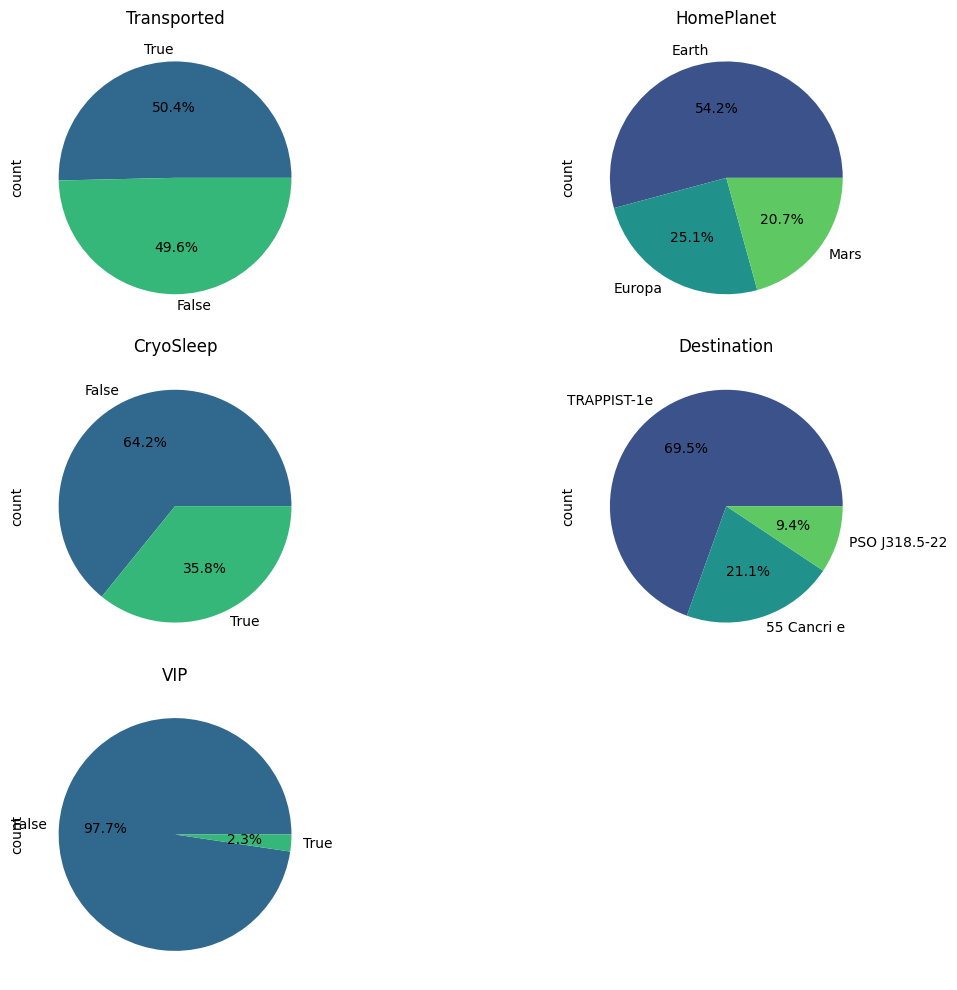

In [10]:
cols = ['Transported','HomePlanet','CryoSleep','Destination','VIP']
fig,axes = plt.subplots(3,2,figsize=(12,10))
axes = axes.flatten()
for i,col in enumerate(cols) :
    counts = df[col].value_counts()
    
    # generate viridis-like colors
    colors = sns.color_palette("viridis", n_colors=len(counts))
    
    counts.plot(
        kind='pie',
        ax=axes[i],
        colors=colors,
        autopct='%1.1f%%'
    )
    
    axes[i].set_title(col)

# remove extra empty subplot
axes[-1].remove()
plt.tight_layout()
plt.show()

* most of the people home planet were earth
* Terappist-1e was the first in count of destinations
* only 2.3% of the people used vip

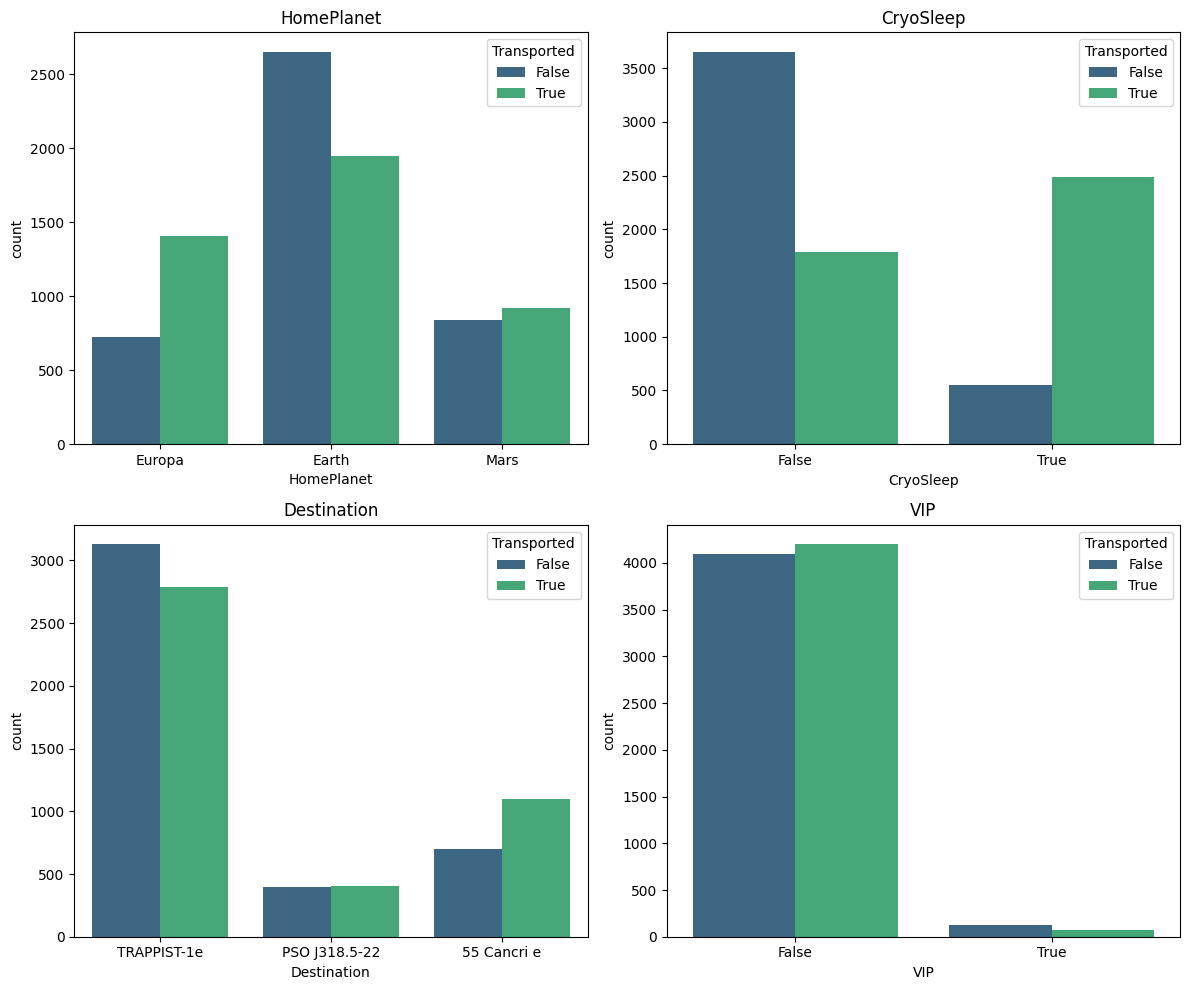

In [11]:
cols = ['HomePlanet','CryoSleep','Destination','VIP']

fig= plt.figure(figsize=(12, 10))

for i, col in enumerate(cols):
    ax = fig.add_subplot(2,2,i+1)
    sns.countplot(data=df,x=col , ax = ax, hue = 'Transported',palette='viridis')
    ax.set_title(col)

fig.tight_layout()
plt.show()

* most of transported people destination was Trappist-1e
* it seems like most of the people who had cryosleep was transported
* although earth was the most in count it had less transported than not transported

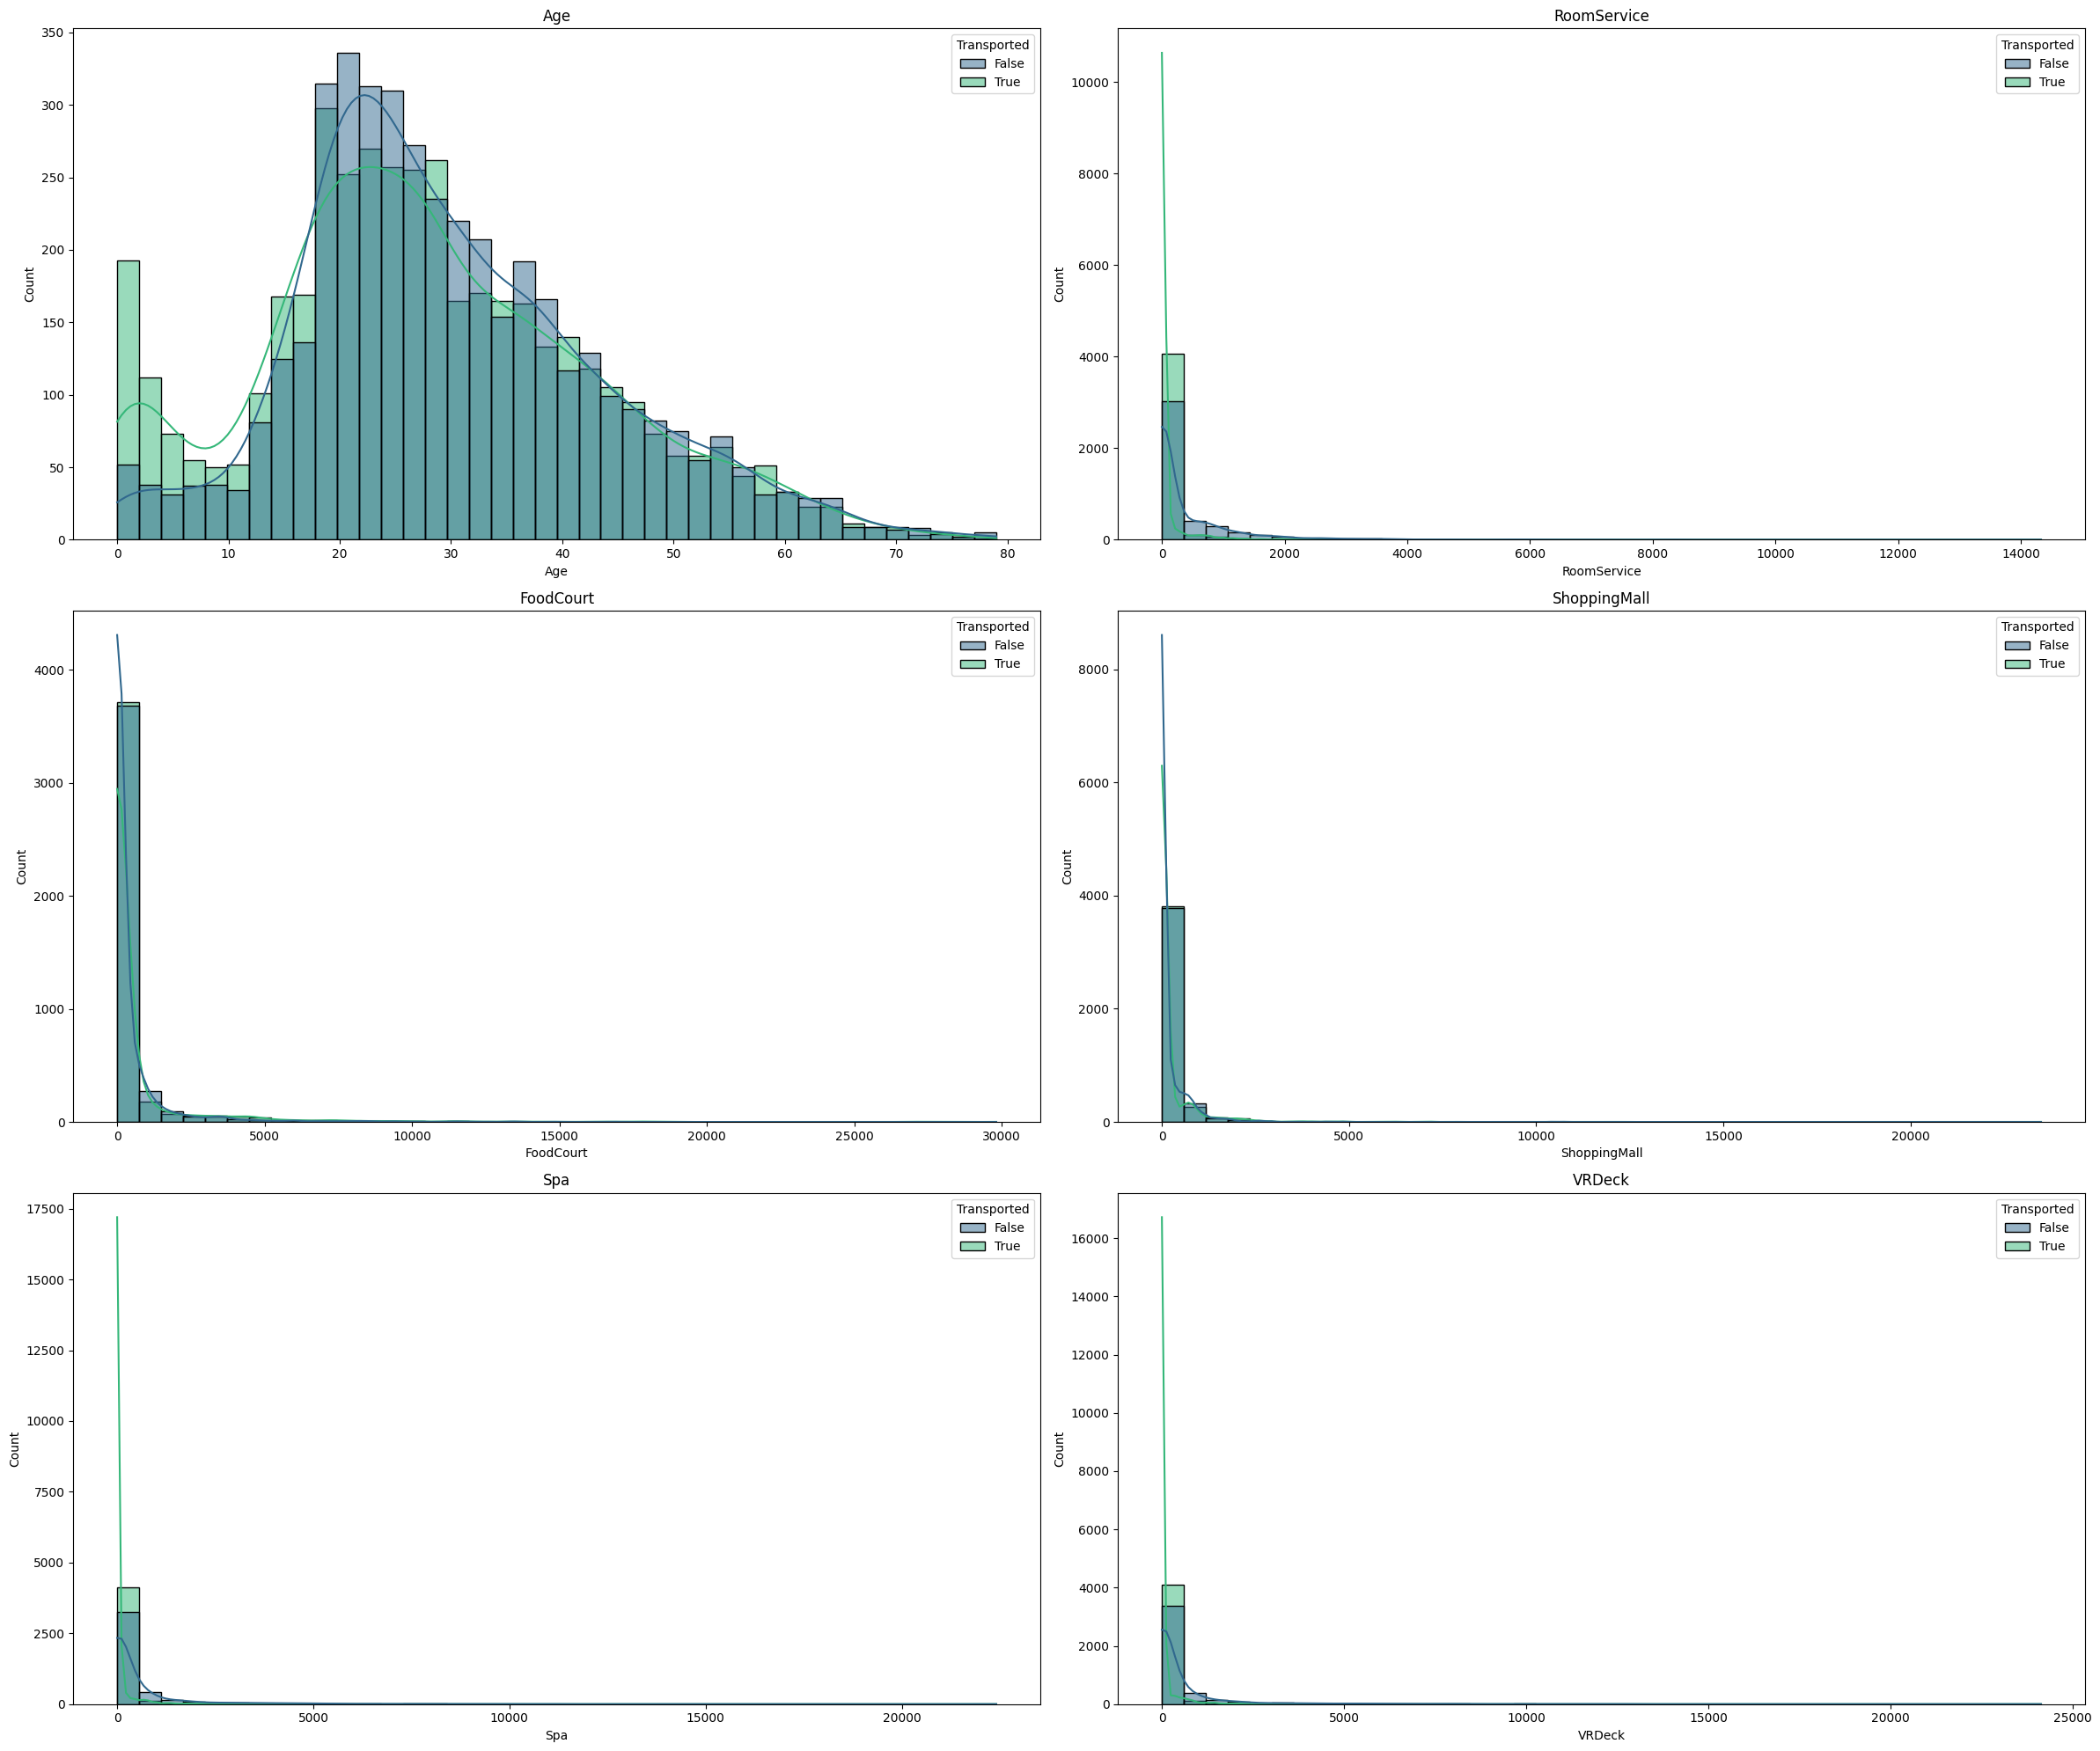

In [12]:
cont = ['Age','RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
fig2 = plt.figure(figsize = (24,20))
for i , col in enumerate(cont):
    ax = fig2.add_subplot(3,2,i+1)
    sns.histplot(data = df, x=col , ax = ax,kde=True,bins=40, hue='Transported',palette='viridis')
    ax.set_title(col)
fig2.tight_layout()
plt.show()

* most of the people who transported were between 20 -30
* vrdeck and spa seems to be similar
* seems like transported people did'nt use any money in spaceship

# Data preprocessing

i want to concat train and test data to be all in one for some processing and seperate them later
ideas i have for this part: 
* passenger id is not helpfull but we can exctract the group info from it
* cabin must be splited into 3 features
* it is possible to add 2 features based on passenger id : is_alone and group size
* name and passenger id and Cabin can be dropped

In [13]:
#concat part
df['is_train']=1
df_test['is_train']=0
df_all = pd.concat([df,df_test],axis = 0).reset_index(drop=True)
print("concat is done!")

concat is done!


In [14]:
df_all[['Cabin_deck','Cabin_num','Cabin_side']]=df_all['Cabin'].str.split('/',expand = True)
df_all['Cabin_num']= pd.to_numeric(df_all['Cabin_num'],errors = 'coerce')

In [15]:
df_all['Group']=df_all['PassengerId'].str.split('_').str[0]
df_all['Group'] = pd.to_numeric(df_all['Group'],errors='coerce')
df_all['Group_size']=df_all.groupby('Group')['Group'].transform('count')
df_all['is_alone']=(df_all['Group_size']==1).astype(int)

In [16]:
df_all.drop(['Name','Cabin','PassengerId'],axis=1,inplace=True)

In [17]:
df_all.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,is_train,Cabin_deck,Cabin_num,Cabin_side,Group,Group_size,is_alone
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,B,0.0,P,1,1,1
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,1,F,0.0,S,2,1,1
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,1,A,0.0,S,3,2,0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,1,A,0.0,S,3,2,0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1,F,1.0,S,4,1,1


# Missing value

In [18]:
df_all.isna().sum().sort_values()

Group              0
is_train           0
is_alone           0
Group_size         0
RoomService      263
VRDeck           268
Age              270
Destination      274
Spa              284
HomePlanet       288
FoodCourt        289
VIP              296
Cabin_side       299
Cabin_deck       299
Cabin_num        299
ShoppingMall     306
CryoSleep        310
Transported     4277
dtype: int64

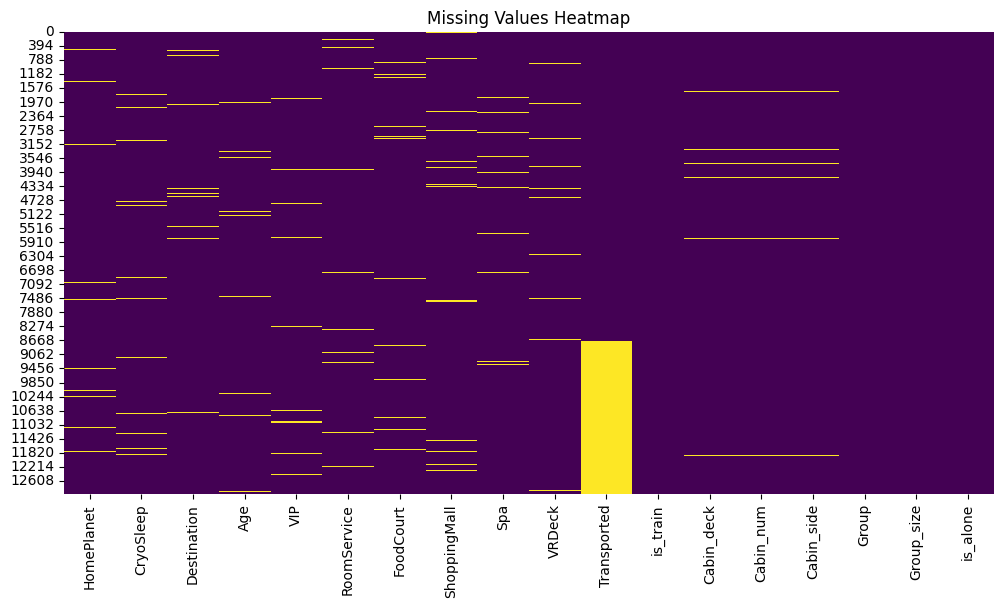

In [19]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_all.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

i would like to handel missing values by joint distribution first

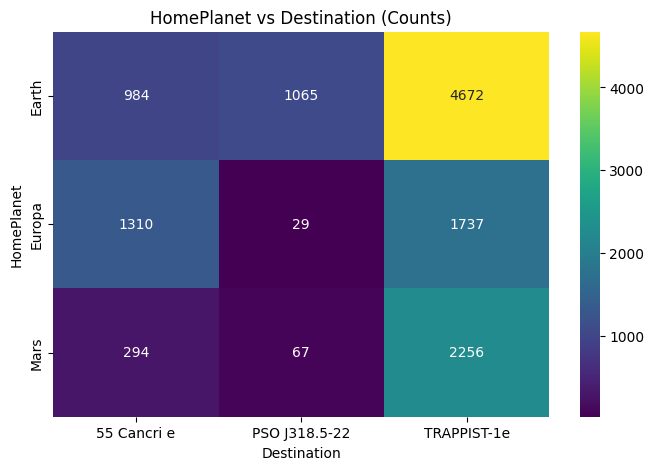

In [20]:
temp = df_all.groupby(['HomePlanet','Destination']).size().unstack()

plt.figure(figsize=(8,5))
sns.heatmap(temp, annot=True, fmt='d', cmap='viridis')

plt.title("HomePlanet vs Destination (Counts)")
plt.show()

In [21]:
mode_destination = df_all.groupby('HomePlanet')['Destination'].agg(lambda x:x.mode()[0])

In [22]:
print(mode_destination)

HomePlanet
Earth     TRAPPIST-1e
Europa    TRAPPIST-1e
Mars      TRAPPIST-1e
Name: Destination, dtype: object


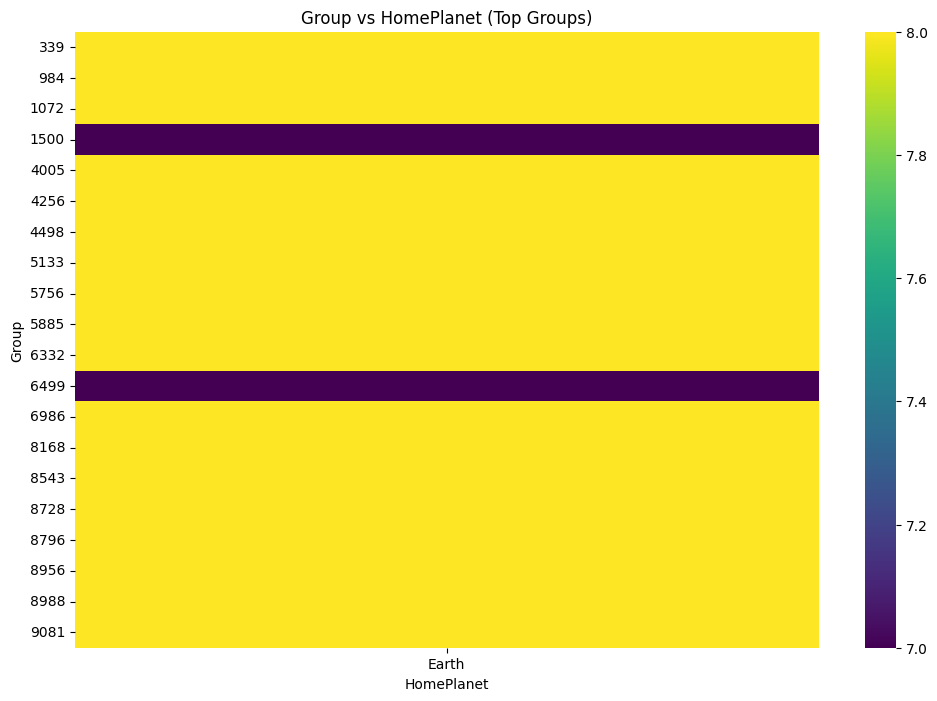

In [23]:
# Count top N groups
top_n = 20  # Adjust this number if needed
top_groups = df_all['Group'].value_counts().head(top_n).index

# Filter the dataset to only top groups
df_top = df_all[df_all['Group'].isin(top_groups)]

# Group vs HomePlanet heatmap
group_hp_ct = pd.crosstab(df_top['Group'], df_top['HomePlanet'])

plt.figure(figsize=(12, 8))
sns.heatmap(group_hp_ct, cmap='viridis', cbar=True)
plt.title('Group vs HomePlanet (Top Groups)')
plt.xlabel('HomePlanet')
plt.ylabel('Group')
plt.show()

In [24]:
mode_hp = df_all.groupby('Group')['HomePlanet'].agg(lambda x:x.mode()[0] if not x.mode().empty else None)
df_all['HomePlanet']=df_all['HomePlanet'].fillna(df_all['Group'].map(mode_hp))
df_all['Destination']=df_all['Destination'].fillna('TRAPPIST-1e')

In [25]:
df_all['VIP'].fillna('False',inplace=True)

/tmp/ipykernel_16/3780853514.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_all['VIP'].fillna('False',inplace=True)


In [26]:
money = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_all.loc[df_all['CryoSleep']==True,money]=0

In [27]:
df_all.isna().sum()

HomePlanet       157
CryoSleep        310
Destination        0
Age              270
VIP                0
RoomService      170
FoodCourt        180
ShoppingMall     175
Spa              177
VRDeck           177
Transported     4277
is_train           0
Cabin_deck       299
Cabin_num        299
Cabin_side       299
Group              0
Group_size         0
is_alone           0
dtype: int64

In [28]:
df_all[money]=df_all[money].fillna(0)

In [29]:
df_all['total_spending'] = df_all['Spa']+df_all['RoomService']+df_all['FoodCourt']+df_all['ShoppingMall']+df_all['VRDeck']
df_all.loc[df_all['total_spending']==0,'CryoSleep']=True

In [30]:
df_all.isna().sum()

HomePlanet         157
CryoSleep          174
Destination          0
Age                270
VIP                  0
RoomService          0
FoodCourt            0
ShoppingMall         0
Spa                  0
VRDeck               0
Transported       4277
is_train             0
Cabin_deck         299
Cabin_num          299
Cabin_side         299
Group                0
Group_size           0
is_alone             0
total_spending       0
dtype: int64

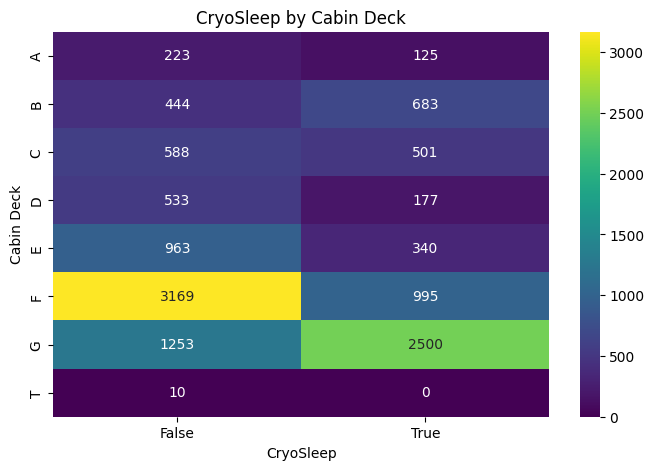

In [31]:
CD_CS = pd.crosstab(df_all['Cabin_deck'],df_all['CryoSleep'])
plt.figure(figsize=(8,5))
sns.heatmap(CD_CS, cmap="viridis", annot=True, fmt='d')
plt.title('CryoSleep by Cabin Deck')
plt.xlabel('CryoSleep')
plt.ylabel('Cabin Deck')
plt.show()

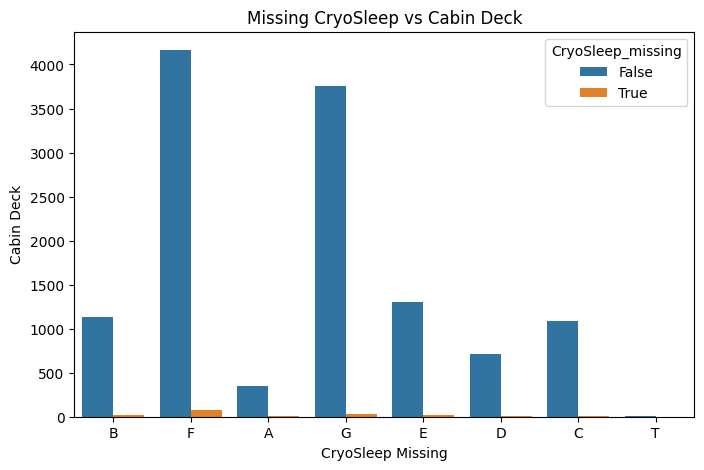

In [32]:
df_all['CryoSleep_missing']= df_all['CryoSleep'].isnull()
plt.figure(figsize=(8,5))
sns.countplot(data=df_all,x='Cabin_deck',hue='CryoSleep_missing')
plt.title('Missing CryoSleep vs Cabin Deck')
plt.xlabel('CryoSleep Missing')
plt.ylabel('Cabin Deck')
plt.show()

In [33]:
df_all.isna().sum()

HomePlanet            157
CryoSleep             174
Destination             0
Age                   270
VIP                     0
RoomService             0
FoodCourt               0
ShoppingMall            0
Spa                     0
VRDeck                  0
Transported          4277
is_train                0
Cabin_deck            299
Cabin_num             299
Cabin_side            299
Group                   0
Group_size              0
is_alone                0
total_spending          0
CryoSleep_missing       0
dtype: int64

In [34]:
df_all['CryoSleep'] = df_all.groupby('Group')['CryoSleep'] \
    .transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)


/tmp/ipykernel_16/1385847135.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)


In [35]:
df_all['CryoSleep'].fillna(False, inplace=True)

/tmp/ipykernel_16/363618228.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_all['CryoSleep'].fillna(False, inplace=True)
/tmp/ipykernel_16/363618228.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all['CryoSleep'].fillna(False, inplace=True)


In [36]:
df_all['Cabin_deck'] = df_all.groupby('Group')['Cabin_deck'] \
    .transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)
df_all['Cabin_side'] = df_all.groupby('Group')['Cabin_side'] \
    .transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)
df_all['Cabin_num'] = df_all.groupby('Group')['Cabin_num'] \
    .transform(lambda x: x.fillna(x.median()) if not x.mode().empty else x)

In [37]:
df_all['Cabin_deck'].fillna(df_all['Cabin_deck'].mode()[0], inplace=True)
df_all['Cabin_side'].fillna(df_all['Cabin_side'].mode()[0], inplace=True)
df_all['Cabin_num'].fillna(df_all['Cabin_num'].median(), inplace=True)

/tmp/ipykernel_16/3213217014.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_all['Cabin_deck'].fillna(df_all['Cabin_deck'].mode()[0], inplace=True)
/tmp/ipykernel_16/3213217014.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [38]:
df_all['HomePlanet'] = df_all.groupby('Cabin_deck')['HomePlanet'] \
    .transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)

In [39]:
df_all['Age']=df_all.groupby('HomePlanet')['Age']\
    .transform(lambda x:x.fillna(x.median()))

In [40]:
df_all.isna().sum()

HomePlanet              0
CryoSleep               0
Destination             0
Age                     0
VIP                     0
RoomService             0
FoodCourt               0
ShoppingMall            0
Spa                     0
VRDeck                  0
Transported          4277
is_train                0
Cabin_deck              0
Cabin_num               0
Cabin_side              0
Group                   0
Group_size              0
is_alone                0
total_spending          0
CryoSleep_missing       0
dtype: int64

# Encoding categorical features

In [41]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   HomePlanet         12970 non-null  object 
 1   CryoSleep          12970 non-null  bool   
 2   Destination        12970 non-null  object 
 3   Age                12970 non-null  float64
 4   VIP                12970 non-null  object 
 5   RoomService        12970 non-null  float64
 6   FoodCourt          12970 non-null  float64
 7   ShoppingMall       12970 non-null  float64
 8   Spa                12970 non-null  float64
 9   VRDeck             12970 non-null  float64
 10  Transported        8693 non-null   object 
 11  is_train           12970 non-null  int64  
 12  Cabin_deck         12970 non-null  object 
 13  Cabin_num          12970 non-null  float64
 14  Cabin_side         12970 non-null  object 
 15  Group              12970 non-null  int64  
 16  Group_size         129

In [42]:
catcol = ['HomePlanet','Destination','Cabin_side','Cabin_deck']
df_all = pd.get_dummies(df_all,columns=catcol)

In [43]:
df_all['CryoSleep'] = df_all['CryoSleep'].map({False: 0, True: 1})
df_all['VIP'] = df_all['VIP'].map({False: 0, True: 1})

In [44]:
df_all['VIP'] = df_all['VIP'].fillna(0).astype(int)

In [45]:
df_all.drop('CryoSleep_missing', axis=1, inplace=True)

In [46]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CryoSleep                  12970 non-null  int64  
 1   Age                        12970 non-null  float64
 2   VIP                        12970 non-null  int64  
 3   RoomService                12970 non-null  float64
 4   FoodCourt                  12970 non-null  float64
 5   ShoppingMall               12970 non-null  float64
 6   Spa                        12970 non-null  float64
 7   VRDeck                     12970 non-null  float64
 8   Transported                8693 non-null   object 
 9   is_train                   12970 non-null  int64  
 10  Cabin_num                  12970 non-null  float64
 11  Group                      12970 non-null  int64  
 12  Group_size                 12970 non-null  int64  
 13  is_alone                   12970 non-null  int

In [47]:
train_df = df_all[df_all['is_train']==1]
test_df = df_all[df_all['is_train']==0]

In [48]:
train_df['Transported'] = train_df['Transported'].map({False:0, True:1})

/tmp/ipykernel_16/1441305826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Transported'] = train_df['Transported'].map({False:0, True:1})


In [49]:
x=train_df.drop(['Transported','is_train'],axis=1)
y=train_df['Transported']
test_df=test_df.drop(['Transported','is_train'],axis=1)
x_train , x_test , y_train , y_test = train_test_split(x,y,random_state =42,test_size =0.2)

In [50]:
clf = LazyClassifier(verbose=0,ignore_warnings=True,custom_metric=None)
models , prediction = clf.fit(x_train,x_test,y_train,y_test)

In [51]:
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
LGBMClassifier                 0.810236           0.810173  0.897140   
CatBoostClassifier             0.806786           0.806677  0.900352   
XGBClassifier                  0.795860           0.795835  0.890067   
SVC                            0.791259           0.791144  0.876969   
ExtraTreesClassifier           0.790109           0.790297  0.856222   
RandomForestClassifier         0.788959           0.789113  0.875503   
NuSVC                          0.782059           0.782133  0.872929   
LogisticRegression             0.780334           0.779795  0.874632   
LinearSVC                      0.778033           0.777574  0.872925   
AdaBoostClassifier             0.776883           0.776626  0.855320   
CalibratedClassifierCV         0.776883           0.776446  0.872998   
SGDClassifier                  0.773433           0.773265  0.86

In [52]:
final_model = LGBMClassifier(n_estimators=500,learning_rate=0.05,max_depth=-1,random_state=42)
final_model.fit(x_train,y_train)

LGBMClassifier(learning_rate=0.05, n_estimators=500, random_state=42)

In [53]:
pred = final_model.predict(x_test)
print(accuracy_score(y_test,pred))

0.7987349051178838


In [54]:
finmodel = LGBMClassifier(n_estimators=500,learning_rate=0.05,max_depth=-1,random_state=42)
finmodel.fit(x,y)
final_pred = finmodel.predict(test_df)

In [55]:
test_org=pd.read_csv(r'/kaggle/input/competitions/spaceship-titanic/test.csv')
p_id = test_org['PassengerId']
submission = pd.DataFrame({
    'PassengerId':p_id,
    'Transported':final_pred.astype(bool)
})
submission.to_csv('Submission.csv',index=False)